In [1]:
from classy import Class
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Function to compute and plot for different neutrino mass configurations
def run_class_with_different_neutrino_masses(m_nu1, m_nu2, m_nu3):
    # Define the cosmological parameters for LambdaCDM + neutrinos
    params = {
        'output': 'mPk',  # Output: matter power spectrum
        'P_k_max_1/Mpc': 3.0,  # Maximum wavenumber for the power spectrum
        'h': 0.67556,          # Reduced Hubble parameter
        'omega_b': 0.022032,   # Baryon density
        'omega_cdm': 0.12038,  # Cold dark matter density
        'n_s': 0.9619,         # Spectral index
        'A_s': 2.215e-9,       # Amplitude of scalar perturbations
        'tau_reio': 0.0925,    # Optical depth to reionization

        # Neutrino related parameters
        'N_ur': 0.046,         # Number of ultra-relativistic species (other than neutrinos)
        'N_ncdm': 3,           # Three non-cold dark matter species (three neutrinos)
        'm_ncdm': f'{m_nu1}, {m_nu2}, {m_nu3}',  # Masses of the three different neutrinos
    }

    # Create a CLASS instance
    cosmo = Class()

    # Set the parameters and run CLASS
    cosmo.set(params)
    cosmo.compute()

    # Retrieve the background quantities
    background = cosmo.get_background()

    # Extract the scale factor and neutrino energy densities for the three species
    z = background['z']
    R = 1 / (1 + z)
    
    # Extract energy density for each of the three neutrino species
    rho_nu1 = background['(.)rho_ncdm[0]']  # Energy density of the first neutrino
    rho_nu2 = background['(.)rho_ncdm[1]']  # Energy density of the second neutrino
    rho_nu3 = background['(.)rho_ncdm[2]']  # Energy density of the third neutrino

    # Multiply by R^4 for each species and plot the result
    rho_nu1_R4 = rho_nu1 * R**4
    rho_nu2_R4 = rho_nu2 * R**4
    rho_nu3_R4 = rho_nu3 * R**4

    # Plotting the results
    plt.plot(R, rho_nu1_R4, label=f'Neutrino 1: $m_\\nu = {m_nu1}$ eV')
    plt.plot(R, rho_nu2_R4, label=f'Neutrino 2: $m_\\nu = {m_nu2}$ eV', linestyle='--')
    plt.plot(R, rho_nu3_R4, label=f'Neutrino 3: $m_\\nu = {m_nu3}$ eV', linestyle=':')

    # Customize the plot
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Scale factor R')
    plt.ylabel(r'Neutrino energy density $\rho_\nu \times R^4$ [some units]')
    plt.title('Energy Density vs Scale Factor for Different Neutrino Masses')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Clean up CLASS instance
    cosmo.struct_cleanup()
    cosmo.empty()

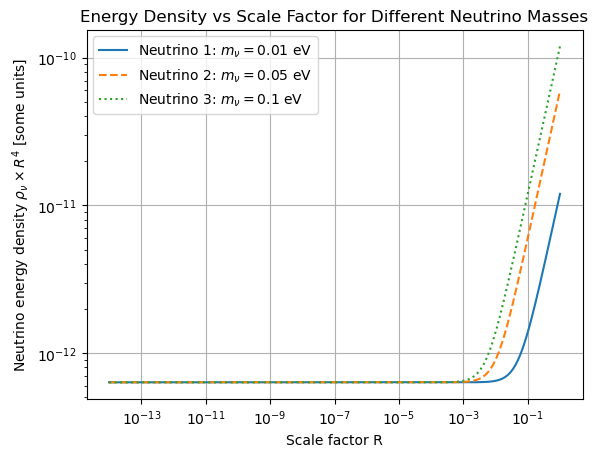

In [3]:
# Example usage: Define three different masses for the neutrinos
m_nu1 = 0.01  # Mass of the first neutrino in eV
m_nu2 = 0.05  # Mass of the second neutrino in eV
m_nu3 = 0.10  # Mass of the third neutrino in eV

# Run CLASS with three different neutrino masses
run_class_with_different_neutrino_masses(m_nu1, m_nu2, m_nu3)

In [25]:
# --- Now this is the time to check whether is the value of neutrinos in my model

# --- Define the cosmological parameters for LambdaCDM + neutrinos ---
params = {
    'output': 'mPk',  # Output: matter power spectrum
    'P_k_max_1/Mpc': 3.0,  # Maximum wavenumber for the power spectrum
    'h': 0.69556,          # Reduced Hubble parameter
    'omega_b': 0.022032,   # Baryon density
    'omega_cdm': 0.12038,  # Cold dark matter density
    'n_s': 0.9619,         # Spectral index
    'A_s': 2.215e-9,       # Amplitude of scalar perturbations
    'tau_reio': 0.0925,    # Optical depth to reionization

    # Neutrino and axion related parameters
    'N_ur': 0.0,
    'N_ncdm': '1',           # one species: neutrinos
    'deg_ncdm': '3',         # 3 degenerate neutrinos

    # Basic settings
    # 'use_ncdm_psd_files': '0, 0',
    
    # Extra settings
    'perturbed_recombination': 'yes',       # consider perturbed recombination
    # 'ceff2_ur': 1/3,                        # effective squared sound speed and viscosity parameter
    # 'cvis2_ur': 1/3,                        # effective squared sound speed and viscosity parameter
    'ncdm_quadrature_strategy': '0',    # is the method used for the momentum sampling of the ncdm distribution function: 0, 1, 2, 3
    'ncdm_maximum_q': '15',
    'Number of momentum bins': '150'  # More momentum bins for better resolution

}

In [26]:
# --- SET NEUTRINOS
nuetrino_mass = 0.16  # [eV]
T_neutrinos = 0.71611  # in units of photon temperature [T_gamma]

# prepare list
Neff_base = 3.044


# --- CALL CLASS
cosmoNeutrinos = Class()
cosmoNeutrinos.set(params)
cosmoNeutrinos.set({'m_ncdm': f'{nuetrino_mass}'})     # Masses of neutino
cosmoNeutrinos.set({'T_ncdm': f'{T_neutrinos}'})   # Temperature of neutino
cosmoNeutrinos.compute()

In [27]:
derived_params = cosmoNeutrinos.get_current_derived_parameters(['Neff'])  # derived parameters
deltaNeff = derived_params['Neff']

print("deltaNeff:", deltaNeff)

deltaNeff: 3.039594664360296
